<a href="https://colab.research.google.com/github/sumitsartale4952/Study-_materials/blob/main/Nvida_Stock_Price_Predcition_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# Step 1: Import Required Lib
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load the datasets

df = pd.read_csv("/content/nvda_stock.csv")

In [3]:
# Step 3: Data Exploration '

df.head()

,Date,Open,High,Low,Close,Volume
0,2010-01-04,0.424242,0.426763,0.415074,0.423784,800204000
1,2010-01-05,0.422179,0.434556,0.422179,0.429972,728648000
2,2010-01-06,0.429743,0.433639,0.425617,0.432722,649168000
3,2010-01-07,0.430430,0.432264,0.421033,0.424242,547792000
4,2010-01-08,0.420804,0.428139,0.418283,0.425159,478168000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4108 non-null   object 
 1   Open    4108 non-null   float64
 2   High    4108 non-null   float64
 3   Low     4108 non-null   float64
 4   Close   4108 non-null   float64
 5   Volume  4108 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 192.7+ KB


In [5]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [9]:
# Step 4: Data Preprocessing

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

df.drop('Date', axis=1, inplace=True)

In [10]:
df.dtypes

,0
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Month,int32
Day,int32
Year,int32


In [11]:
# Step 6: divide the data into X and y variable

X= df.drop('Close',axis=1)
y=df['Close']

In [12]:
# Step 7: Split the datasets into train and testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Step 8: Feature Engineering

# create the instance
scaler = StandardScaler()

# fit and transform the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Step 9: Building Neural Network (ANN)

model = Sequential()

model.add(Dense(units = 128, activation = 'relu', input_dim = X_train.shape[1]))
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dense(units = 32, activation = 'relu'))
model.add(Dense(units = 1, activation = 'linear'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:

# Step 10 : Compile the model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001,      # learning Rate
    clipnorm = 1.0)           # gradient Clipping

model.compile(
    optimizer = optimizer,
    loss = 'mean_squared_error',
    metrics = ['r2_score']
)

In [40]:
# Step 10 :  Learning Rate Scheduler

# option 1: Exponential Decay

lr_scheduler = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps= 1000,
    decay_rate=0.9
)

# option 2: Cosin Decay
lr_scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=1000
)

# option 3: Warmup
lr_scheduler = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    end_learning_rate=0.0001,
    power=1.0
)

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Step 11: Train model

history = model.fit(
    X_train, y_train,
    epochs = 20,
    batch_size = 32,
    validation_data = (X_test, y_test),
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.2686 - r2_score: 0.9995 - val_loss: 1.4791 - val_r2_score: 0.9994
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2585 - r2_score: 0.9995 - val_loss: 0.8547 - val_r2_score: 0.9997
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1475 - r2_score: 0.9995 - val_loss: 0.7374 - val_r2_score: 0.9997
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0162 - r2_score: 0.9996 - val_loss: 1.1240 - val_r2_score: 0.9995
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2024 - r2_score: 0.9995 - val_loss: 0.6661 - val_r2_score: 0.9997
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9445 - r2_score: 0.9996 - val_loss: 0.7850 - val_r2_score: 0.9997
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9473 - r2_score: 0.9996 - val_loss: 0.8180 - val_r2_score: 0.9997
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1101 - r2_score: 0.9995 - val_loss: 3.2039

In [33]:
# Step 12 : Evulate

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Mean Squared Error: 1.3296996229966445
Mean Absolute Error: 0.5482931874891849
R-squared Score: 0.9994638030520729


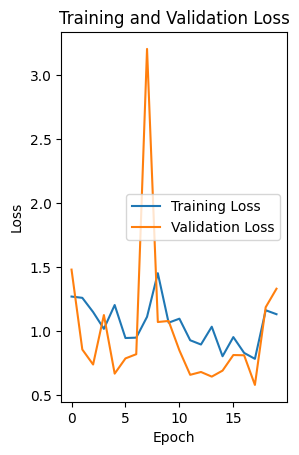

In [36]:
# Step 13 : Plot Training History
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

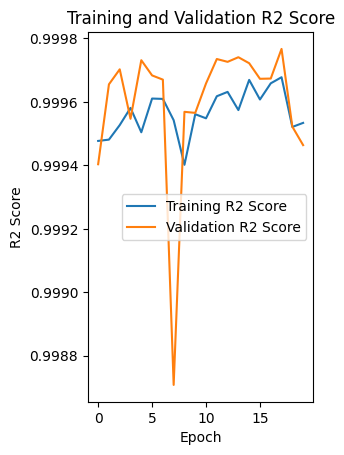

In [37]:
# Step 13 : plot the Metrics

plt.subplot(1, 2, 2)
plt.plot(history.history['r2_score'], label='Training R2 Score')
plt.plot(history.history['val_r2_score'], label='Validation R2 Score')
plt.title('Training and Validation R2 Score')
plt.xlabel('Epoch')
plt.ylabel('R2 Score')
plt.legend()